In [2]:
import numpy as np
import pandas as pd
from ins_pricing import bayesopt as ropt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.multiprocessing as mp
from pathlib import Path
import sys
import os

repo_root = Path.cwd()
if not (repo_root / 'ins_pricing').exists():
    for parent in repo_root.parents:
        if (parent / 'ins_pricing').exists():
            repo_root = parent
            sys.path.insert(0, str(repo_root))
            break

os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [ ]:
# 参数定义
base_dir = Path.cwd()
if (base_dir / 'Data').exists():
    data_dir = base_dir / 'Data'
elif (base_dir / 'ins_pricing/examples/modelling/Data').exists():
    data_dir = base_dir / 'ins_pricing/examples/modelling/Data'
else:
    raise FileNotFoundError(
        'Data directory not found. Expected ./Data or ./ins_pricing/examples/modelling/Data')
prop_test = 0.25
rand_seed = 13
percentile_tgt = 0.95
tgt = 'response'
wght = 'weights'
# ['od', 'ctp', 'tp', 'ctp_bi', 'ctp_pd', 'tp_bi', 'tp_pd']
model_list = ['od']
model_cate = ['bc']  # ['f', 's', 'bc']
model_names = []
for chr in model_cate:
    model_names += list(map(lambda x: x + '_' + chr, model_list))
# 定义建模因子数据集
feature_list = [
    'age_owner', 'gender_owner',
    'plt_zone', 'cheling_year', 'carbrand', 'carkind',
    'cartype', 'grpcode', 'pl', 'power_type',
    'price', 'qualitymax', 'seat_num', 'trans_type',
    'absflag', 'airbagcount',
    'btype', 'lastnum_2y_bi', 'lastnum_2y_ctp', 'cover',
    'L', 'N', 'cover_chg', 'delay_ins',
    'medication_mrk', 'owner_insured', 'tplimit',
    'channel', 'dpt',
    'chd_mileage_day', 'chd_mileage_total', 'chd_num_atten', 'chd_num_prov',
    'chd_r_unfam_road', 'chd_speed_total', 'chd_time_total', 'chd_triprate_prov'
]
# 定义分类变量
categorical_features = [
    'gender_owner',
    'plt_zone', 'cheling_year', 'carbrand', 'carkind',
    'cartype', 'grpcode', 'pl', 'power_type',
    'price', 'seat_num', 'trans_type',
    'absflag', 'airbagcount',
    'btype', 'lastnum_2y_bi', 'lastnum_2y_ctp', 'cover',
    'cover_chg', 'delay_ins',
    'medication_mrk', 'owner_insured',
    'channel', 'dpt'
]

model_dict = {}
for model in model_names:
    print('Model of %s is processing' % model)
    raw = pd.read_csv(data_dir / f'{model}.csv', low_memory=False)
    # 数据预处理
    raw.fillna(0, inplace=True)
    print(f"Data of {model} is loaded")
    train_data, test_data = train_test_split(
        raw, test_size=prop_test, random_state=rand_seed)
    print(f"Data of {model} is splitted into train and test sets")
    model_basic = ropt.BayesOptModel(
        train_data, test_data,
        model, tgt, wght, feature_list,
        cate_list=categorical_features,
        prop_test=0.25, rand_seed=rand_seed, epochs=50,
        use_resn_data_parallel=False,
        use_ft_data_parallel=False,
        use_gnn_data_parallel=False,
        use_resn_ddp=False,
        use_ft_ddp=False,
        use_gnn_ddp=False,
    )

    print(f"XgbBayesOptModel of {model} begin to train")
    model_basic.bayesopt_xgb(max_evals=100)
    model_basic.trainers['xgb'].save()
    print(f"Xgb model of {model} finished and saved")
    print(f"ResNetBayesOptModel of {model} begin to train")
    model_basic.bayesopt_resnet(max_evals=50)
    model_basic.trainers['resn'].save()
    print(f"ResNet model of {model} finished and saved")
    print(f"FTTransformerBayesOptModel of {model} begin to train")
    model_basic.bayesopt_ft(max_evals=50)
    model_basic.trainers['ft'].save()
    print(f"FT Transformer model of {model} finished and saved")

    model_dict[model] = model_basic
    ropt.free_cuda()

Model of od_bc is processing
Data of od_bc is loaded
Data of od_bc is splitted into train and test sets


[I 2025-12-01 13:32:07,216] A new study created in memory with name: no-name-628bc43c-4d94-4a3d-af27-d97d481bba8d


XgbBayesOptModel of od_bc begin to train
[Optuna][Xgboost] Trial 1/100 started (trial_id=0).
>>> XGBoost using GPU ID: 0 (Single GPU Mode)


[I 2025-12-01 13:32:25,685] Trial 0 finished with value: 5.53502036826229 and parameters: {'learning_rate': 2.214259910139153e-05, 'gamma': 9999.477871003879, 'max_depth': 4, 'n_estimators': 80, 'min_child_weight': 4200, 'reg_alpha': 9.111637636641483e-09, 'reg_lambda': 0.002882112896587406, 'tweedie_variance_power': 1.3555342078130157}. Best is trial 0 with value: 5.53502036826229.


[Optuna][Xgboost] Trial 1/100 finished (status=OK).
[Optuna][Xgboost] Trial 2/100 started (trial_id=1).
>>> XGBoost using GPU ID: 0 (Single GPU Mode)


...

[Optuna][ResNet] Trial 2/50 finished (status=OK).
[Optuna][ResNet] Trial 3/50 started (trial_id=2).
>>> Multi-GPU detected: 2 devices. Adjusted min_bs to 128.
>>> DataLoader config: Batch Size=4610, Accum Steps=1, Workers=8
>>> ResNetSequential executing on device: cuda:0


[I 2025-12-01 15:02:52,799] Trial 2 finished with value: 13.04519982986053 and parameters: {'learning_rate': 0.0037783275952901394, 'hidden_dim': 24, 'block_num': 8, 'tw_power': 1.8366550621633484}. Best is trial 1 with value: 5.230239912999994.


[Optuna][ResNet] Trial 3/50 finished (status=OK).
[Optuna][ResNet] Trial 4/50 started (trial_id=3).
>>> Multi-GPU detected: 2 devices. Adjusted min_bs to 128.
>>> DataLoader config: Batch Size=953, Accum Steps=8, Workers=8
>>> ResNetSequential executing on device: cuda:0


[I 2025-12-01 15:05:52,456] Trial 3 finished with value: 5.236690336361269 and parameters: {'learning_rate': 0.00016172371029503406, 'hidden_dim': 20, 'block_num': 10, 'tw_power': 1.2097167961475996}. Best is trial 1 with value: 5.230239912999994.


[Optuna][ResNet] Trial 4/50 finished (status=OK).
[Optuna][ResNet] Trial 5/50 started (trial_id=4).
>>> Multi-GPU detected: 2 devices. Adjusted min_bs to 128.
>>> DataLoader config: Batch Size=128, Accum Steps=64, Workers=8
>>> ResNetSequential executing on device: cuda:0


In [ ]:
for model in model_names:
    model_dict[model].plot_lift(model_label='Xgboost', pred_nme='pred_xgb')

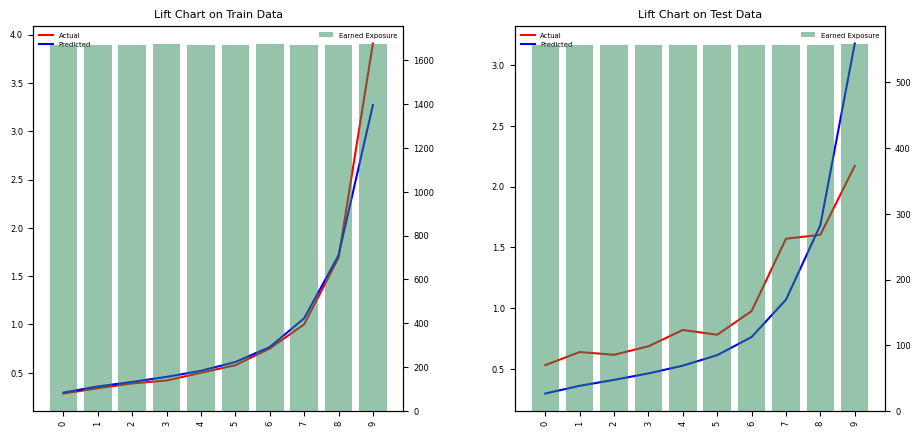

In [ ]:
for model in model_names:
    model_dict[model].plot_lift(model_label='ResNet', pred_nme='pred_resn')

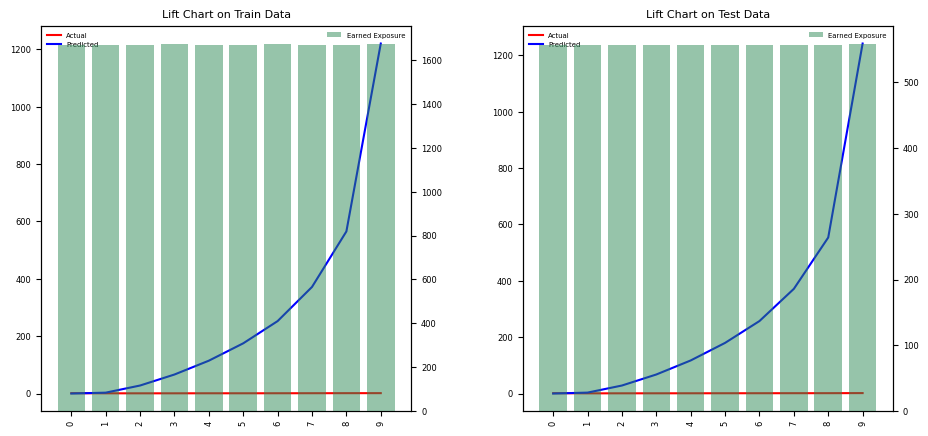

In [ ]:
for model in model_names:
    model_dict[model].plot_lift(
        model_label='FT Transformer', pred_nme='pred_ft')